In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import time
import pickle

from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor


import discretize
from simpeg import (
    maps,
    Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

from simpeg.electromagnetics import time_domain as tdem

from simpeg.utils.solver_utils import get_default_solver

from simpeg.meta import MultiprocessingMetaSimulation #DaskMetaSimulation

In [2]:
Solver = get_default_solver()
Solver

pymatsolver.direct.pardiso.Pardiso

# set up models and mesh

In [3]:
sigma_overburden = 0.01
depth_overburden = 60

sigma_alteration = 0.05
thickness_alteration = 150
depth_alteration = 300

sigma_stock = 0.001
width_stock = 400
depth_stock = depth_alteration

sigma_host = 0.002

sigma_air = 1e-8

rx_times = np.logspace(np.log10(2e-5), np.log10(2e-3), 20)


In [4]:
def diffusion_distance(sigma, t):
    return 1260*np.sqrt(t/sigma)

In [5]:
diffusion_distance(sigma_host, 8e-3)

np.float64(2520.0)

In [6]:
tx_height = np.r_[30]

rx_x = (np.linspace(-700, 700, 29))[::2]
rx_y = rx_x[::2]
rx_z = tx_height
rx_locs = discretize.utils.ndgrid([rx_x, rx_y, rx_z])
# rx_x

In [7]:
rx_x

array([-700., -600., -500., -400., -300., -200., -100.,    0.,  100.,
        200.,  300.,  400.,  500.,  600.,  700.])

In [8]:
rx_y

array([-700., -500., -300., -100.,  100.,  300.,  500.,  700.])

In [9]:
len(rx_locs)

120

In [10]:
source_list = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times, orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list.append(src)

survey = tdem.Survey(source_list)

In [11]:
global_mesh = discretize.TreeMesh.read_UBC(f"td-octree-mt-mill/octree_mesh.txt")

In [12]:
global_mesh

OcTreeMesh,0.03% filled
Level,Number of cells
3,304
4,1484
5,1056
6,2032
7,4798
8,17284
9,58255
10,231048
Total,316261


In [13]:
model = np.ones(global_mesh.n_cells)*sigma_air
model[global_mesh.cell_centers[:, 2] < 0] = sigma_host

# alteration
extent_alteration = width_stock/2 + thickness_alteration
inds_alteration = (
    (global_mesh.cell_centers[:, 0] > -extent_alteration) &
    (global_mesh.cell_centers[:, 0] < extent_alteration) &
    (global_mesh.cell_centers[:, 1] > -extent_alteration) &
    (global_mesh.cell_centers[:, 1] < extent_alteration) &
    (global_mesh.cell_centers[:, 2] > -depth_alteration) &
    (global_mesh.cell_centers[:, 2] < 0)
)
model[inds_alteration] = sigma_alteration

# stock
extent_stock = width_stock/2
inds_stock = (
    (global_mesh.cell_centers[:, 0] > -extent_stock) &
    (global_mesh.cell_centers[:, 0] < extent_stock) &
    (global_mesh.cell_centers[:, 1] > -extent_stock) &
    (global_mesh.cell_centers[:, 1] < extent_stock) &
    (global_mesh.cell_centers[:, 2] > -depth_stock) &
    (global_mesh.cell_centers[:, 2] < 0)
)
model[inds_stock] = sigma_stock

# overburden
extent_overburden = 1500 # mesh dependent
inds_overburden = (
    (global_mesh.cell_centers[:, 0] > -extent_overburden) &
    (global_mesh.cell_centers[:, 0] < extent_overburden) &
    (global_mesh.cell_centers[:, 1] > -extent_overburden) &
    (global_mesh.cell_centers[:, 1] < extent_overburden) &
    (global_mesh.cell_centers[:, 2] > -depth_overburden) &
    (global_mesh.cell_centers[:, 2] < 0)
)
model[inds_overburden] = sigma_overburden

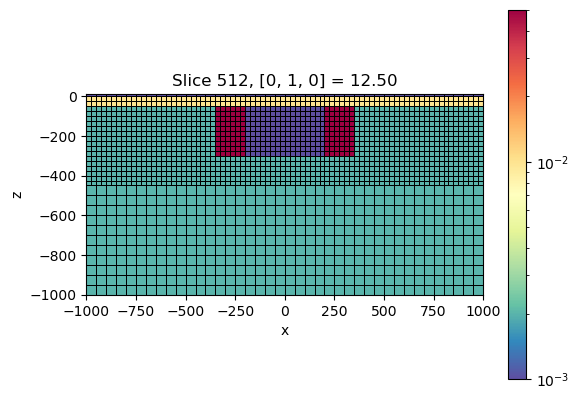

In [14]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    global_mesh.plot_slice(
        model,
        pcolor_opts={
            "norm":LogNorm(vmin=1e-3), "cmap":"Spectral_r"},
        grid_opts={"color":"k", "lw":0.5},
        # grid=True,
        ax=ax,
        normal="Y",
    )[0], ax=ax
)
ax.set_xlim(np.r_[-1, 1]*1000)
ax.set_ylim(np.r_[-1000, 10])
ax.set_aspect(1)

In [15]:
n_times_invert = 20

In [16]:
# fig, ax = plt.subplots(1, 1)
# line = 7
# ax.semilogy(rx_x, dpred_values[:,line*len(rx_x):(line+1)*len(rx_x)].T, color="k", label="uniform", lw=1);

In [17]:
# set up local meshes

active_cells_map = maps.InjectActiveCells(global_mesh, global_mesh.cell_centers[:, 2]<0, value_inactive=np.log(1e-8))

refine_depth = 300
# def get_local_mesh(src):
mesh_list = []
x1 = np.mean(rx_locs[:, 0]) - (np.sum(global_mesh.h[0]) / 2)
x2 = np.mean(rx_locs[:, 1]) - (np.sum(global_mesh.h[1]) / 2)
x3 = np.mean(rx_locs[:, 2]) - (np.sum(global_mesh.h[2]) / 2)

for src in survey.source_list:
# src = survey.source_list[0]
    mesh_local = discretize.TreeMesh(global_mesh.h, origin=global_mesh.origin, diagonal_balance=True)
    refine_points = discretize.utils.ndgrid(
        np.r_[src.location[0]],
        np.r_[src.location[1]],
        np.linspace(-refine_depth, src.location[2], 40)
    )
    mesh_local.refine_points(
        refine_points,
        level=-1,
        padding_cells_by_level=[2, 2, 2, 2],
        finalize=True,
        diagonal_balance=True
    )
    mesh_list.append(mesh_local)

    mesh_local.x0

In [18]:
mesh_local

OcTreeMesh,0.00% filled
Level,Number of cells
2,28
3,252
4,252
5,225
6,416
7,598
8,744
9,796
10,288


In [19]:
len(mesh_list)

120

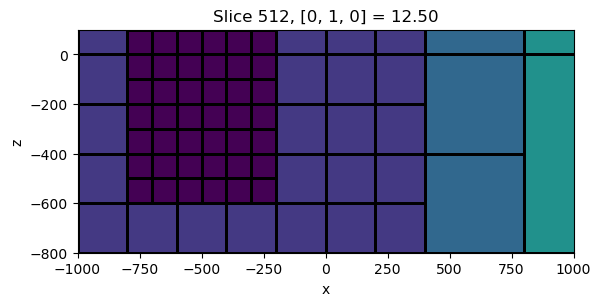

In [20]:
fig, ax = plt.subplots(1, 1)
mesh_local = mesh_list[32]
mesh_local.plot_slice(
    np.log10(mesh_local.cell_volumes), ax=ax, normal="Y",
    grid_opts={"color":"k", "lw":1}
)
ax.set_xlim(np.r_[-1, 1]*1000)
ax.set_ylim(np.r_[-800, 100])
ax.set_aspect(1)

In [ ]:
nsteps = 20
time_steps = [
    (1e-6, nsteps),
    (3e-6, nsteps),
    (1e-5, nsteps),
    (3e-5, nsteps),
    (1e-4, 20),
]


mappings = []
sims = []

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)
    mappings.append(tile_map)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )

    local_survey = tdem.Survey([survey.source_list[ii]])
    sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap() * local_actmap
        )
    )


sim = MultiprocessingMetaSimulation(sims, mappings)

/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:229: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  super().__init__(simulations, mappings)
/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:248: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  sim_chunk = MetaSimulation(


/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened 

In [22]:
true_model = np.log(model)[active_cells_map.active_cells]

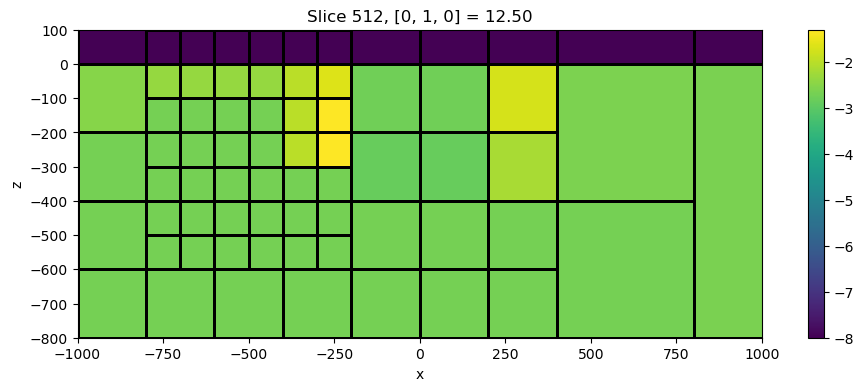

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

ind = 32
mesh_local = mesh_list[ind]

plt.colorbar(
    mesh_local.plot_slice(
        np.log10(sims[ind].sigmaMap * sim.mappings[ind] * true_model), ax=ax, normal="Y",
        grid_opts={"color":"k", "lw":1}
    )[0]
)
ax.set_xlim(np.r_[-1, 1]*1000)
ax.set_ylim(np.r_[-800, 100])
ax.set_aspect(1)

In [24]:
dobs = sim.dpred(true_model)

In [25]:
dobs_obj = Data(survey=survey, dobs=dobs)

In [26]:
dobs_reshaped = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)

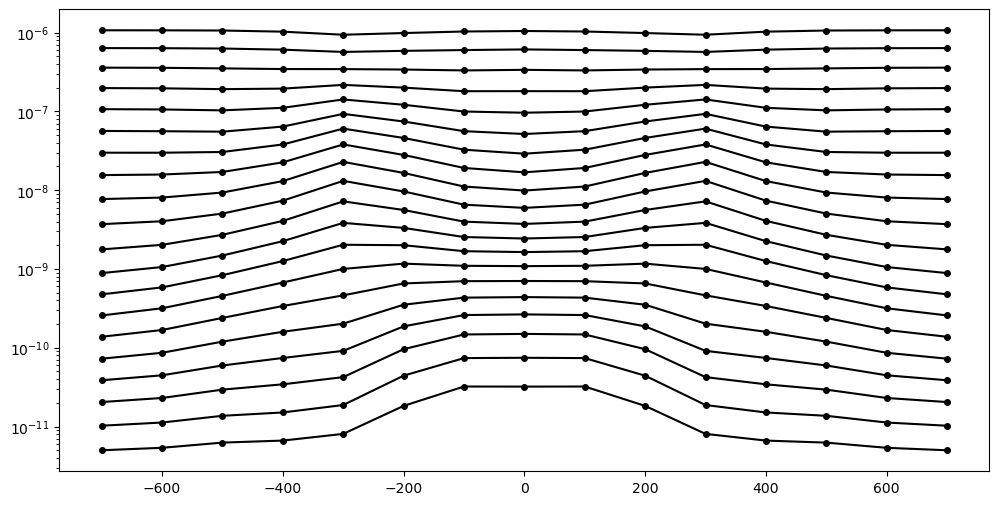

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.semilogy(rx_x, -dobs_reshaped[3, :, :], "-ok", ms=4);

In [28]:
relative_error = 0.05
noise_floor = 1e-12

In [29]:
data_invert = Data(
    survey, dobs=dobs,
    standard_deviation=np.abs(dobs)*relative_error + noise_floor
)

In [30]:
dmis = data_misfit.L2DataMisfit(simulation=sim, data=data_invert)
reg = regularization.WeightedLeastSquares(
    global_mesh,
    active_cells=active_cells_map.active_cells,
)

In [31]:
opt = optimization.InexactGaussNewton(maxIter=20, maxIterCG=50)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)


/home/lheagy/git/simpeg/simpeg/simpeg/optimization.py:1061: FutureWarning: InexactCG.maxIterCG has been deprecated, please use InexactCG.cg_maxiter. It will be removed in version 0.26.0 of SimPEG.
  self.maxIterCG = val


In [32]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=10, n_pw_iter=1)
cool_beta = directives.BetaSchedule(coolingFactor=2, coolingRate=4)
# Options for outputting recovered models and predicted data for each beta.
save_iteration = directives.SaveOutputDictEveryIteration(
    saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2113: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.saveOnDisk = save_on_disk
/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2114: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.saveOnDisk


In [33]:
# The directives are defined as a list.
directives_list = [
    starting_beta,
    cool_beta,
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [34]:
m0 = np.log(sigma_host)*np.ones(np.sum(active_cells_map.active_cells))

# view inversion results

In [57]:
mrec_dict = {}
for i in range(1, 6):
    mrec_dict[i] = np.load(f"InversionModel_2026-06-01-16-20_0{i}.npz", allow_pickle=True)["arr_0"].item()

In [58]:
mrec_dict[5].keys()

dict_keys(['iter', 'beta', 'phi_d', 'phi_m', 'f', 'm', 'dpred'])

In [77]:
misfits = np.array([mrec_dict[i+1]["phi_d"] for i in range(len(mrec_dict))])
model_norms = np.array([mrec_dict[i+1]["phi_m"] for i in range(len(mrec_dict))])

In [85]:
global_map = maps.ExpMap() * active_cells_map

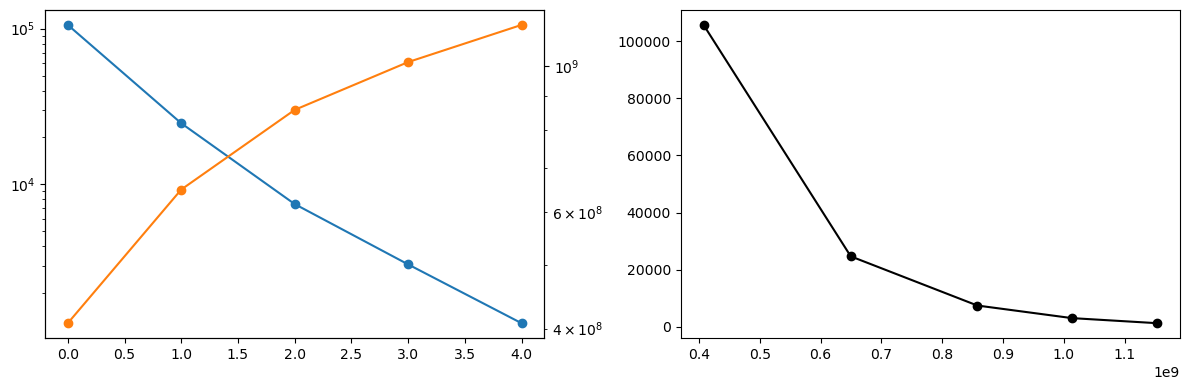

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].semilogy(misfits, "-C0o")
ax1 = ax[0].twinx()
ax1.semilogy(model_norms, "-C1o")

ax[1].plot(model_norms, misfits, "-ko")

plt.tight_layout()

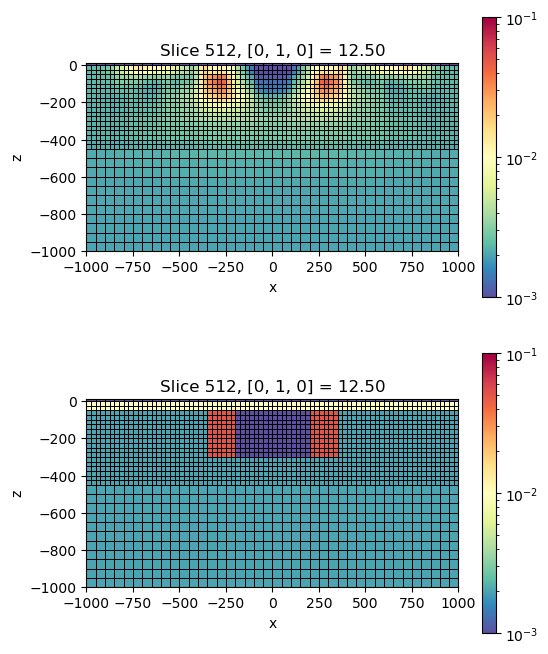

In [70]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

iter = 4
norm = LogNorm(vmin=1e-3, vmax=1e-1)
plt.colorbar(
    global_mesh.plot_slice(
        global_map * mrec_dict[iter]["m"],
        pcolor_opts={
            "norm":norm, "cmap":"Spectral_r"},
        grid_opts={"color":"k", "lw":0.5},
        # grid=True,
        ax=ax[0],
        normal="Y",
    )[0], ax=ax[0]
)

plt.colorbar(
    global_mesh.plot_slice(
        model,
        pcolor_opts={
            "norm":norm, "cmap":"Spectral_r"},
        grid_opts={"color":"k", "lw":0.5},
        # grid=True,
        ax=ax[1],
        normal="Y",
    )[0], ax=ax[1]
)

for a in ax.flatten():
    a.set_xlim(np.r_[-1, 1]*1000)
    a.set_ylim(np.r_[-1000, 10])
    a.set_aspect(1)

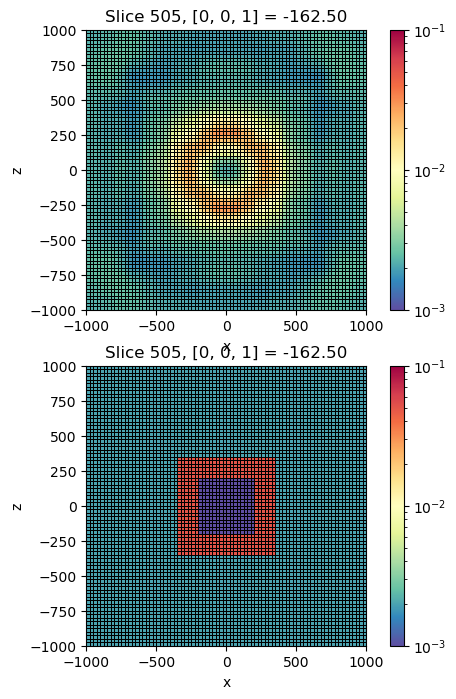

In [71]:
fig, ax = plt.subplots(2, 1, figsize=(6, 8))

ind = 505
norm = LogNorm(vmin=1e-3, vmax=1e-1)
plt.colorbar(
    global_mesh.plot_slice(
        global_map * mrec_dict[iter]["m"],
        pcolor_opts={
            "norm":norm, "cmap":"Spectral_r"},
        grid_opts={"color":"k", "lw":0.5},
        # grid=True,
        ind=ind,
        ax=ax[0],
        normal="Z",
    )[0], ax=ax[0]
)

plt.colorbar(
    global_mesh.plot_slice(
        model,
        pcolor_opts={
            "norm":norm, "cmap":"Spectral_r"},
        grid_opts={"color":"k", "lw":0.5},
        # grid=True,
        ind=ind,
        ax=ax[1],
        normal="Z",
    )[0], ax=ax[1]
)

for a in ax.flatten():
    a.set_xlim(np.r_[-1, 1]*1000)
    a.set_ylim(np.r_[-1, 1]*1000)
    a.set_aspect(1)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

data_ind = 3
iter = 5

ax.semilogy(rx_x, -mrec_dict[iter]["dpred"].reshape(len(rx_y), len(rx_x), n_times_invert)[data_ind, :, :], "-C0o", ms=4);
ax.semilogy(rx_x, -dobs_reshaped[data_ind, :, :], "-k", ms=4);
